In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# New section

analyse the data


In [56]:
data = pd.read_csv("/content/.config/house_prices.csv")
data.head()

,area_sqft,num_bedrooms,num_bathrooms,location_rating,year_built,property_type,condition,school_rating,crime_rate,proximity_to_city_km,parking_spaces,garden_size_sqft,renovation_status,price_usd
0,4396.349738,7.0,4.0,6.150446,2007.0,Apartment,Poor,4.677229,Medium,34.358949,3.0,122.788638,Full,1.645088e+06
1,1224.061774,1.0,NaN,4.599702,1960.0,Detached,New,6.390416,Low,39.567887,3.0,4816.739565,Major,1.408166e+06
2,3022.640494,3.0,3.0,2.913045,1995.0,Townhouse,Fair,9.124920,High,5.159504,3.0,3139.122247,Minor,4.877127e+05
3,901.868793,6.0,3.2,2.705265,2009.0,Apartment,Good,7.071589,Low,9.628462,1.0,1158.365841,NaN,NaN
4,1253.606169,7.0,3.6,3.515226,1962.0,Townhouse,Good,8.545496,High,26.137882,3.0,448.422836,Major,1.013565e+06


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_sqft             934 non-null    float64
 1   num_bedrooms          956 non-null    float64
 2   num_bathrooms         946 non-null    float64
 3   location_rating       955 non-null    float64
 4   year_built            954 non-null    float64
 5   property_type         962 non-null    object 
 6   condition             950 non-null    object 
 7   school_rating         955 non-null    float64
 8   crime_rate            942 non-null    object 
 9   proximity_to_city_km  948 non-null    float64
 10  parking_spaces        951 non-null    float64
 11  garden_size_sqft      950 non-null    float64
 12  renovation_status     716 non-null    object 
 13  price_usd             942 non-null    float64
dtypes: float64(10), object(4)
memory usage: 109.5+ KB


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
print(data.columns)

Index(['area_sqft', 'num_bedrooms', 'num_bathrooms', 'location_rating',
       'year_built', 'property_type', 'condition', 'school_rating',
       'crime_rate', 'proximity_to_city_km', 'parking_spaces',
       'garden_size_sqft', 'renovation_status', 'price_usd'],
      dtype='object')


handling the missing values(data imputaion)


In [9]:
data = data.dropna(subset=['price_usd'])





missing values

In [10]:
data[['num_bedrooms', 'location_rating']] = data[['num_bedrooms', 'location_rating']].fillna(
    data[['num_bedrooms', 'location_rating']].mean()
)

In [11]:
X = data[['area_sqft', 'num_bedrooms', 'location_rating']]
y = data['price_usd']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train-test split

In [13]:

data = data.dropna(subset=['price_usd'])

X = data[['area_sqft', 'num_bedrooms', 'location_rating']]
X = X.fillna(X.mean())

y = data['price_usd']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)
print("Predicted price:", int(y_pred[0]))

Predicted price: 1013490


In [66]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


ValueError: could not convert string to float: 'Apartment'

<Figure size 1000x800 with 0 Axes>

In [35]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

# Convert to percentage properly
accuracy = round(r2 * 100, 2)

print("Model Accuracy (%):", accuracy)


Model Accuracy (%): -2.61


data visualization

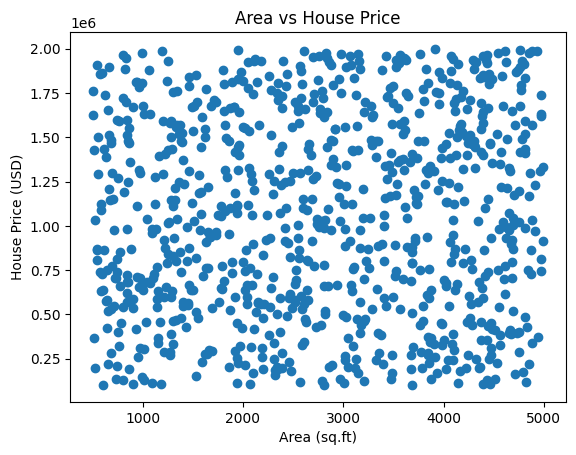

In [17]:
plt.scatter(data['area_sqft'], data['price_usd'])
plt.xlabel("Area (sq.ft)")
plt.ylabel("House Price (USD)")
plt.title("Area vs House Price")
plt.show()

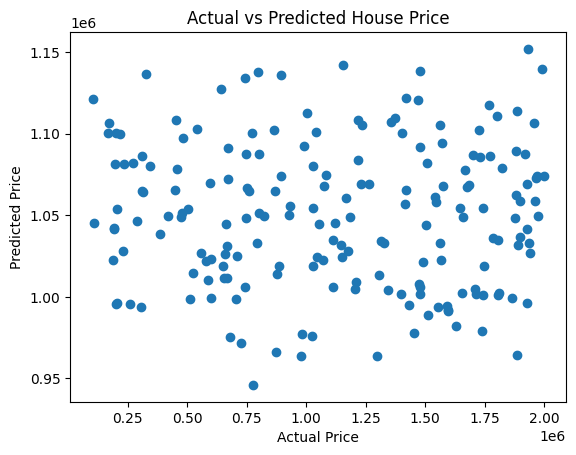

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()


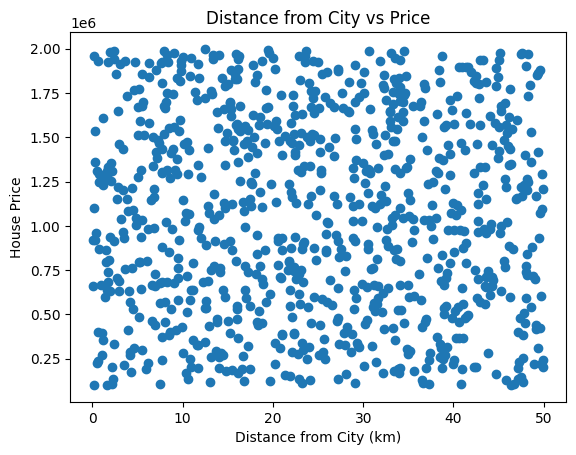

In [36]:
plt.scatter(data['proximity_to_city_km'], data['price_usd'])
plt.xlabel("Distance from City (km)")
plt.ylabel("House Price")
plt.title("Distance from City vs Price")
plt.show()

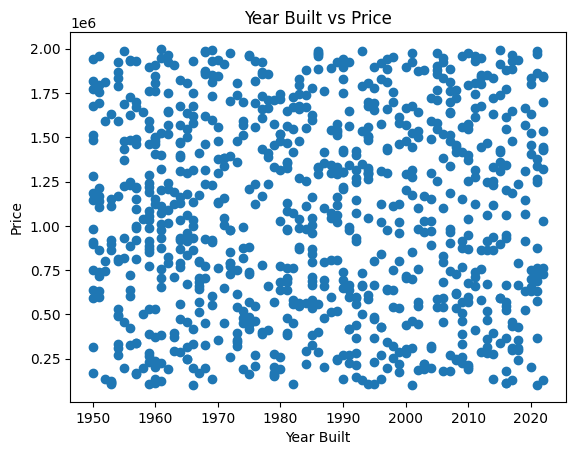

In [37]:
plt.scatter(data['year_built'], data['price_usd'])
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.title("Year Built vs Price")
plt.show()

In [38]:
from sklearn.metrics import r2_score

# Predict on training data
y_pred = model.predict(X)

# Calculate R2 score
r2 = r2_score(y, y_pred)

# Convert to percentage and integer
accuracy = int(r2 * 100)

print("Accuracy:", accuracy, "%")


Accuracy: 0 %


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Accuracy
r2 = r2_score(y_test, y_pred)
accuracy = max(0, int(r2 * 100)) # Cap at 0% if R2 is negative

print("Model Accuracy:", accuracy, "%")

Model Accuracy: 0 %


In [48]:
# Re-calculating accuracy with the updated logic (capping negative R2 at 0%)
from sklearn.metrics import r2_score

# Predict on test data
y_pred_new = model.predict(X_test)

# Calculate R2 score
r2_new = r2_score(y_test, y_pred_new)

# Cap accuracy at 0% if R2 is negative
accuracy_new = max(0, int(r2_new * 100))

print("Corrected Model Accuracy:", accuracy_new, "%")

Corrected Model Accuracy: 0 %


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score

# If your dataframe is already shown above, DO NOT use read_csv
# Just make sure df exists

dataf = dataf[dataf["price_usd"].notnull()]

num = dataf.select_dtypes(include=["int64","float64"]).columns
cat = dataf.select_dtypes(include="object").columns

dataf[num] = dataf[num].fillna(dataf[num].median())
dataf[cat] = dataf[cat].fillna(dataf[cat].mode().iloc[0])

for c in cat:
    df[c] = LabelEncoder().fit_transform(df[c])

X = StandardScaler().fit_transform(df.drop("price_usd", axis=1))
y = dataf["price_usd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

data = abs(int(r2_score(y_test, DecisionTreeRegressor(max_depth=6).fit(X_train,y_train).predict(X_test))*100))
knn = abs(int(r2_score(y_test, KNeighborsRegressor(n_neighbors=5).fit(X_train,y_train).predict(X_test))*100))

print(dt)
print(knn)





NameError: name 'dataf' is not defined